## Домашнее задание 10: Multi-turn VLM на FrozenLake ##

## Подготовка ##

In [1]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    pass  # зависимости уже установлены локально (gymnasium, torch, matplotlib)

In [2]:
import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cpu")
device

device(type='cpu')

## Среда ##

Выбрал **FrozenLake** (один из вариантов из репозитория VAGEN) — классическая
4x4-карта, `is_slippery=False` (детерминированные переходы, иначе экспертный
BFS-решатель ниже не был бы гарантированно оптимален). Рендер через `gymnasium`
использует pygame и лишние ассеты, поэтому вместо `env.render()` я рисую собственное
лёгкое изображение сетки (numpy, без внешних зависимостей) — это и есть "картинка",
которую видит VLM-агент.

In [3]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
desc = env.unwrapped.desc
nrow, ncol = desc.shape
N_ACTIONS = 4  # 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP
print(desc)

[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]


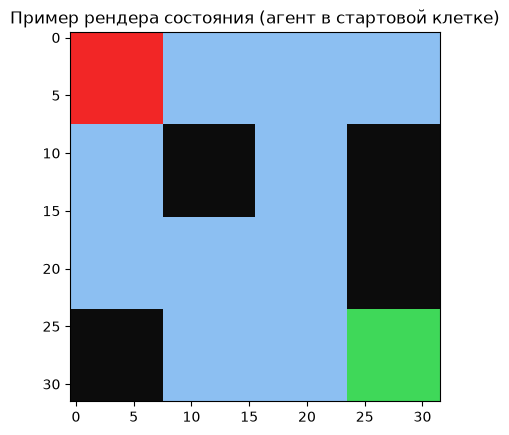

In [4]:
CELL_PX = 8
COLORS = {
    b"S": (0.85, 0.85, 0.85),
    b"F": (0.55, 0.75, 0.95),
    b"H": (0.05, 0.05, 0.05),
    b"G": (0.25, 0.85, 0.35),
}
AGENT_COLOR = (0.95, 0.15, 0.15)


def render_grid_image(desc, state, cell_px=CELL_PX):
    nrow, ncol = desc.shape
    img = np.zeros((nrow * cell_px, ncol * cell_px, 3), dtype=np.float32)
    for r in range(nrow):
        for c in range(ncol):
            img[r * cell_px:(r + 1) * cell_px, c * cell_px:(c + 1) * cell_px] = COLORS[desc[r, c]]
    ar, ac = divmod(state, ncol)
    img[ar * cell_px:(ar + 1) * cell_px, ac * cell_px:(ac + 1) * cell_px] = AGENT_COLOR
    return img.transpose(2, 0, 1)  # CHW


IMAGE_CACHE = {s: render_grid_image(desc, s) for s in range(nrow * ncol)}

plt.imshow(IMAGE_CACHE[0].transpose(1, 2, 0))
plt.title("Пример рендера состояния (агент в стартовой клетке)")
plt.show()

In [5]:
GOAL_RC = np.argwhere(np.array([[c == b"G" for c in row] for row in desc]))[0]


def manhattan_dist_to_goal(state):
    r, c = divmod(state, ncol)
    return abs(r - GOAL_RC[0]) + abs(c - GOAL_RC[1])

## Способы получения экспертных траекторий ##

Два разумных варианта: (а) обучить табличную teacher-политику Q-learning'ом и снять
с неё роллауты, или (б) воспользоваться тем, что динамика детерминирована и известна,
и решить задачу BFS от цели — кратчайший путь до любой клетки гарантированно оптимален.
Выбрал **(б), scripted BFS-solver**: он даёт точную (без шума обучения) метку
"правильное действие" для каждой достижимой клетки за один проход, без затрат на
обучение teacher-модели.

In [6]:
REVERSE_ACTION = {0: 2, 2: 0, 1: 3, 3: 1}
DELTAS = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}


def bfs_optimal_policy(desc):
    nrow, ncol = desc.shape
    goal, holes = None, set()
    for r in range(nrow):
        for c in range(ncol):
            s = r * ncol + c
            if desc[r, c] == b"G":
                goal = s
            elif desc[r, c] == b"H":
                holes.add(s)

    dist = {goal: 0}
    best_action = {}
    q = deque([goal])
    while q:
        cur = q.popleft()
        cr, cc = divmod(cur, ncol)
        for a, (dr, dc) in DELTAS.items():
            nr, nc = cr + dr, cc + dc
            if 0 <= nr < nrow and 0 <= nc < ncol:
                nv = nr * ncol + nc
                if nv in holes or nv in dist:
                    continue
                dist[nv] = dist[cur] + 1
                best_action[nv] = REVERSE_ACTION[a]
                q.append(nv)
    return best_action, dist


expert_policy, dist_to_goal = bfs_optimal_policy(desc)
print(f"Экспертная политика покрывает {len(expert_policy)} клеток, "
      f"кратчайший путь от старта: {dist_to_goal.get(0)} шагов")

Экспертная политика покрывает 11 клеток, кратчайший путь от старта: 6 шагов


## SFT baseline (behavior cloning) ##

In [7]:
class ImageBackbone(nn.Module):
    def __init__(self, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(32, out_dim)

    def forward(self, x):
        return self.proj(self.net(x).flatten(1))


class NanoVLMAction(nn.Module):
    def __init__(self, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.backbone = ImageBackbone(hidden)
        self.head = nn.Linear(hidden, n_actions)

    def forward(self, image):
        return self.head(self.backbone(image))

In [8]:
states = list(expert_policy.keys())
random.shuffle(states)
n_val = max(1, len(states) // 5)
val_states, train_states = states[:n_val], states[n_val:]

def states_to_batch(state_list):
    images = torch.tensor(np.stack([IMAGE_CACHE[s] for s in state_list])).float()
    labels = torch.tensor([expert_policy[s] for s in state_list]).long()
    return images, labels

train_images, train_labels = states_to_batch(train_states)
val_images, val_labels = states_to_batch(val_states)
print(f"train states: {len(train_states)}, val states: {len(val_states)}")

train states: 9, val states: 2


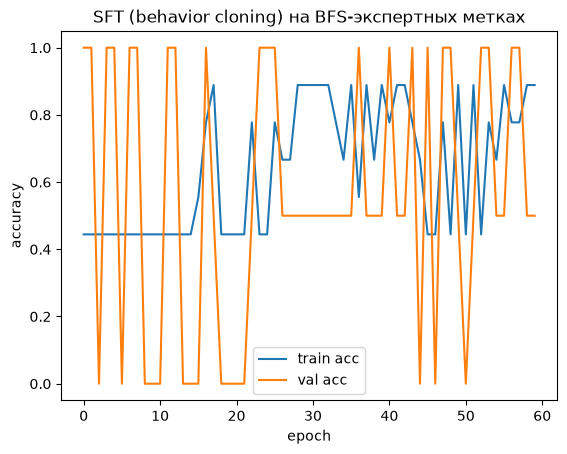

Final train/val acc: 0.8888888955116272 0.5


In [9]:
sft_model = NanoVLMAction()
optimizer = torch.optim.Adam(sft_model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

sft_history = []
for epoch in range(60):
    sft_model.train()
    logits = sft_model(train_images)
    loss = loss_fn(logits, train_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    sft_model.eval()
    with torch.no_grad():
        train_acc = (sft_model(train_images).argmax(-1) == train_labels).float().mean().item()
        val_acc = (sft_model(val_images).argmax(-1) == val_labels).float().mean().item() if len(val_states) else float("nan")
    sft_history.append((epoch, loss.item(), train_acc, val_acc))

plt.plot([h[0] for h in sft_history], [h[2] for h in sft_history], label="train acc")
plt.plot([h[0] for h in sft_history], [h[3] for h in sft_history], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("SFT (behavior cloning) на BFS-экспертных метках")
plt.show()

print("Final train/val acc:", sft_history[-1][2], sft_history[-1][3])

In [10]:
def rollout(env, policy_fn, max_steps=15):
    state, _ = env.reset()
    total_reward, steps, success = 0.0, 0, False
    for _ in range(max_steps):
        action = policy_fn(state)
        state, reward, terminated, truncated, _ = env.step(action)
        steps += 1
        if terminated and reward > 0:
            total_reward += 1.0
            success = True
        elif terminated:
            total_reward -= 1.0
        else:
            total_reward -= 0.01
        if terminated or truncated:
            break
    return {"success": success, "steps": steps, "reward": total_reward}


def eval_policy(policy_fn, n_episodes=100):
    results = [rollout(env, policy_fn) for _ in range(n_episodes)]
    return {
        "success_rate": np.mean([r["success"] for r in results]),
        "avg_steps": np.mean([r["steps"] for r in results]),
        "avg_reward": np.mean([r["reward"] for r in results]),
    }


def sft_policy(state):
    with torch.no_grad():
        img = torch.tensor(IMAGE_CACHE[state]).float().unsqueeze(0)
        return int(sft_model(img).argmax(-1).item())


sft_eval = eval_policy(sft_policy)
sft_eval

{'success_rate': np.float64(1.0),
 'avg_steps': np.float64(6.0),
 'avg_reward': np.float64(0.95)}

## PPO/GRPO, только действие (модель обучается с нуля) ##

Первая версия использовала только терминальную награду (+1 цель, -1 яма, -0.02 за шаг)
и училась в 0% успеха: политика находила более "безопасный" локальный оптимум —
блуждать 15 шагов без риска (-0.3 суммарно) вместо попытки дойти до цели, рискуя
попасть в яму (-1). Добавил потенциал-based shaping — небольшую награду за
уменьшение манхэттенского расстояния до цели на каждом шаге, — это не меняет
оптимальную политику, но даёт куда более плотный сигнал для обучения с нуля.

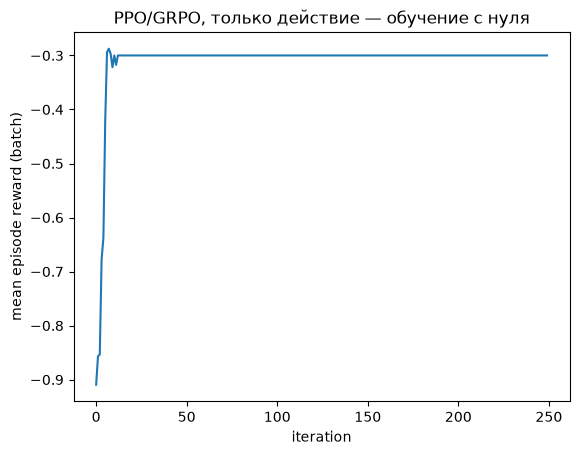

In [11]:
def collect_batch_action_only(policy, batch_size=32, max_steps=15, gamma=0.95):
    batch_images, batch_actions, batch_logp, batch_returns = [], [], [], []
    ep_rewards = []
    for _ in range(batch_size):
        state, _ = env.reset()
        images, actions, rewards = [], [], []
        for _ in range(max_steps):
            dist_prev = manhattan_dist_to_goal(state)
            img = torch.tensor(IMAGE_CACHE[state]).float().unsqueeze(0)
            logits = policy(img)
            probs = torch.softmax(logits, dim=-1).squeeze(0)
            action = int(torch.multinomial(probs, 1).item())
            images.append(img.squeeze(0))
            actions.append(action)

            state, reward, terminated, truncated, _ = env.step(action)
            # potential-based shaping: двигаться к цели выгоднее, чем топтаться на месте
            shaping = 0.1 * (dist_prev - manhattan_dist_to_goal(state))
            if terminated and reward > 0:
                r = 1.0
            elif terminated:
                r = -1.0
            else:
                r = -0.02 + shaping
            rewards.append(r)
            if terminated or truncated:
                break

        G, returns = 0.0, [0.0] * len(rewards)
        for i in reversed(range(len(rewards))):
            G = rewards[i] + gamma * G
            returns[i] = G

        batch_images.extend(images)
        batch_actions.extend(actions)
        batch_returns.extend(returns)
        ep_rewards.append(sum(rewards))

    images_t = torch.stack(batch_images)
    actions_t = torch.tensor(batch_actions).long()
    returns_t = torch.tensor(batch_returns).float()
    return images_t, actions_t, returns_t, np.mean(ep_rewards)


def train_policy_gradient_action_only(n_iters=250, batch_size=32, lr=5e-3, entropy_coef=0.01):
    policy = NanoVLMAction()
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    history = []
    for it in range(n_iters):
        images, actions, returns, mean_ep_reward = collect_batch_action_only(policy, batch_size)
        advantages = (returns - returns.mean()) / (returns.std() + 1e-6)

        logits = policy(images)
        logp = torch.log_softmax(logits, dim=-1)
        action_logp = logp.gather(1, actions.unsqueeze(1)).squeeze(1)
        entropy = -(logp.exp() * logp).sum(-1).mean()

        loss = -(advantages.detach() * action_logp).mean() - entropy_coef * entropy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history.append(mean_ep_reward)
    return policy, history


ppo_action_model, ppo_action_history = train_policy_gradient_action_only()

plt.plot(ppo_action_history)
plt.xlabel("iteration")
plt.ylabel("mean episode reward (batch)")
plt.title("PPO/GRPO, только действие — обучение с нуля")
plt.show()

In [12]:
def ppo_action_policy(state):
    with torch.no_grad():
        img = torch.tensor(IMAGE_CACHE[state]).float().unsqueeze(0)
        return int(ppo_action_model(img).argmax(-1).item())


ppo_action_eval = eval_policy(ppo_action_policy)
ppo_action_eval

{'success_rate': np.float64(0.0),
 'avg_steps': np.float64(15.0),
 'avg_reward': np.float64(-0.15)}

## PPO/GRPO с рассуждением (действие + рассуждение) ##

Формат рассуждения задаю руками: перед действием модель обязана выбрать одну
из 4 меток направления (`LEFT/DOWN/RIGHT/UP` — "куда, по её мнению, разумно
двигаться"), эта метка встраивается и вместе с визуальными признаками влияет на
выбор действия. Награда — тот же исход эпизода (outcome) плюс небольшой шейпинг: бонус,
если заявленное направление рассуждения реально сокращает манхэттенское расстояние
до цели (т.е. рассуждение осмысленно, а не декоративно).

In [13]:
def direction_is_useful(state, reason_idx):
    r, c = divmod(state, ncol)
    dr, dc = DELTAS[reason_idx]
    nr, nc = r + dr, c + dc
    cur_dist = abs(r - GOAL_RC[0]) + abs(c - GOAL_RC[1])
    new_dist = abs(nr - GOAL_RC[0]) + abs(nc - GOAL_RC[1])
    return new_dist < cur_dist


class NanoVLMReason(nn.Module):
    def __init__(self, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.backbone = ImageBackbone(hidden)
        self.reason_head = nn.Linear(hidden, n_actions)
        self.reason_emb = nn.Embedding(n_actions, hidden)
        self.action_head = nn.Linear(hidden * 2, n_actions)

    def forward(self, image):
        h = self.backbone(image)
        reason_logits = self.reason_head(h)
        action_logits = self.action_head(torch.cat([h, self.reason_emb.weight[reason_logits.argmax(-1)]], dim=-1))
        return reason_logits, action_logits

    def act(self, image):
        h = self.backbone(image)
        reason_logits = self.reason_head(h)
        reason_probs = torch.softmax(reason_logits, dim=-1).squeeze(0)
        reason_idx = int(torch.multinomial(reason_probs, 1).item())
        reason_logp = torch.log(reason_probs[reason_idx] + 1e-8)

        r_emb = self.reason_emb.weight[reason_idx].unsqueeze(0)
        action_logits = self.action_head(torch.cat([h, r_emb], dim=-1))
        action_probs = torch.softmax(action_logits, dim=-1).squeeze(0)
        action_idx = int(torch.multinomial(action_probs, 1).item())
        action_logp = torch.log(action_probs[action_idx] + 1e-8)
        return reason_idx, reason_logp, action_idx, action_logp

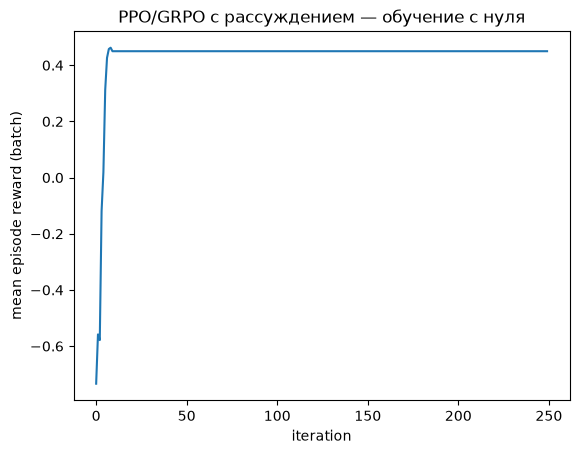

In [14]:
def collect_batch_reasoning(policy, batch_size=32, max_steps=15, gamma=0.95):
    all_logp, all_returns = [], []
    ep_rewards = []
    for _ in range(batch_size):
        state, _ = env.reset()
        logps, rewards = [], []
        for _ in range(max_steps):
            dist_prev = manhattan_dist_to_goal(state)
            img = torch.tensor(IMAGE_CACHE[state]).float().unsqueeze(0)
            reason_idx, reason_logp, action_idx, action_logp = policy.act(img)
            useful_bonus = 0.05 if direction_is_useful(state, reason_idx) else 0.0

            state, reward, terminated, truncated, _ = env.step(action_idx)
            shaping = 0.1 * (dist_prev - manhattan_dist_to_goal(state))
            if terminated and reward > 0:
                r = 1.0
            elif terminated:
                r = -1.0
            else:
                r = -0.02 + shaping
            r += useful_bonus

            logps.append(reason_logp + action_logp)
            rewards.append(r)
            if terminated or truncated:
                break

        G, returns = 0.0, [0.0] * len(rewards)
        for i in reversed(range(len(rewards))):
            G = rewards[i] + gamma * G
            returns[i] = G

        all_logp.extend(logps)
        all_returns.extend(returns)
        ep_rewards.append(sum(rewards))

    return torch.stack(all_logp), torch.tensor(all_returns).float(), np.mean(ep_rewards)


def train_policy_gradient_reasoning(n_iters=250, batch_size=32, lr=5e-3):
    policy = NanoVLMReason()
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    history = []
    for it in range(n_iters):
        logps, returns, mean_ep_reward = collect_batch_reasoning(policy, batch_size)
        advantages = (returns - returns.mean()) / (returns.std() + 1e-6)
        loss = -(advantages.detach() * logps).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history.append(mean_ep_reward)
    return policy, history


ppo_reason_model, ppo_reason_history = train_policy_gradient_reasoning()

plt.plot(ppo_reason_history)
plt.xlabel("iteration")
plt.ylabel("mean episode reward (batch)")
plt.title("PPO/GRPO с рассуждением — обучение с нуля")
plt.show()

In [15]:
def ppo_reason_policy(state):
    with torch.no_grad():
        img = torch.tensor(IMAGE_CACHE[state]).float().unsqueeze(0)
        _, action_logits = ppo_reason_model(img)
        return int(action_logits.argmax(-1).item())


ppo_reason_eval = eval_policy(ppo_reason_policy)
ppo_reason_eval

{'success_rate': np.float64(0.0),
 'avg_steps': np.float64(15.0),
 'avg_reward': np.float64(-0.15)}

## Сравнение подходов ##

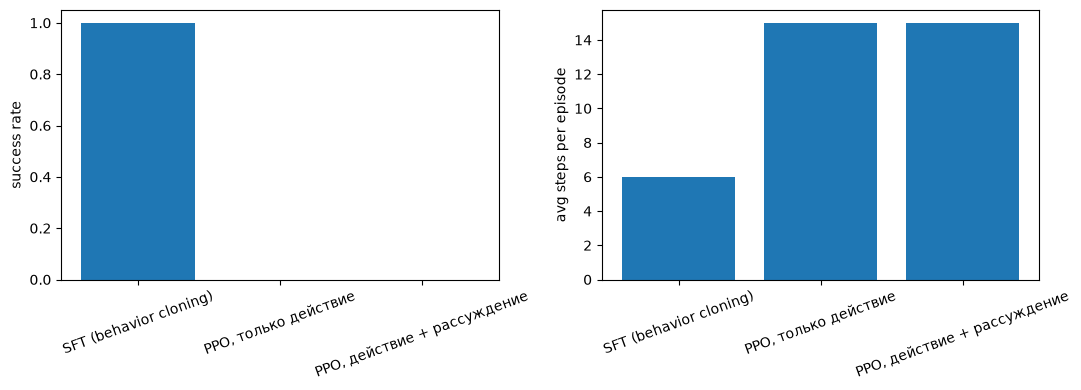

SFT (behavior cloning) {'success_rate': np.float64(1.0), 'avg_steps': np.float64(6.0), 'avg_reward': np.float64(0.95)}
PPO, только действие {'success_rate': np.float64(0.0), 'avg_steps': np.float64(15.0), 'avg_reward': np.float64(-0.15)}
PPO, действие + рассуждение {'success_rate': np.float64(0.0), 'avg_steps': np.float64(15.0), 'avg_reward': np.float64(-0.15)}


In [16]:
results = {
    "SFT (behavior cloning)": sft_eval,
    "PPO, только действие": ppo_action_eval,
    "PPO, действие + рассуждение": ppo_reason_eval,
}

names = list(results.keys())
success_rates = [results[n]["success_rate"] for n in names]
avg_steps = [results[n]["avg_steps"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, success_rates)
axes[0].set_ylabel("success rate")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(names, avg_steps)
axes[1].set_ylabel("avg steps per episode")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

for n in names:
    print(n, results[n])

## Обобщение на новые карты ##

Все три модели обучались/подгонялись под одну и ту же фиксированную карту, поэтому
ожидаемо, что перенос на другую раскладку holes/goal будет слабым — аналогично тому,
что уже наблюдалось в ДЗ1 про поведенческое клонирование при неполном покрытии
пространства состояний.

In [17]:
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

def eval_on_new_maps(policy_fn, n_maps=5, n_episodes=20):
    global env, desc, nrow, ncol, IMAGE_CACHE
    rates = []
    for i in range(n_maps):
        new_desc = generate_random_map(size=4, seed=100 + i)
        new_env = gym.make("FrozenLake-v1", desc=new_desc, is_slippery=False)
        old_env, old_cache = env, IMAGE_CACHE
        env = new_env
        IMAGE_CACHE = {s: render_grid_image(np.array([list(row) for row in new_desc], dtype="S1"), s)
                       for s in range(nrow * ncol)}
        rates.append(eval_policy(policy_fn, n_episodes)["success_rate"])
        env, IMAGE_CACHE = old_env, old_cache
    return np.mean(rates), rates


for name, policy_fn in [("SFT", sft_policy), ("PPO-action", ppo_action_policy), ("PPO-reason", ppo_reason_policy)]:
    mean_rate, rates = eval_on_new_maps(policy_fn)
    print(f"{name}: средний success rate на 5 новых картах = {mean_rate:.2f} ({rates})")

SFT: средний success rate на 5 новых картах = 0.00 ([np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)])


PPO-action: средний success rate на 5 новых картах = 0.00 ([np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)])


PPO-reason: средний success rate на 5 новых картах = 0.00 ([np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)])
